# **Employee Attrition Predictor**


Employee Attrition Early-Warning System

  Jupyter / Google Colab — Cell-by-Cell Version

  Dataset : IBM HR Analytics Employee Attrition (Kaggle)
  
  Run each cell top to bottom in order

In [ ]:
#importing requried libaray

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [ ]:
sns.set_theme(style="whitegrid", palette="pastel", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "#1e1e2e",
    "axes.facecolor":   "#27273f",
    "axes.edgecolor":   "#555",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#999",
    "ytick.color":      "#999",
    "text.color":       "#ddd",
    "grid.color":       "#3a3a5a",
    "figure.dpi":       150,
})

# CELL 2 — STEP 1: Load & Validate Dataset
THE DATASET:
#   1. Go to: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

In [ ]:
print("  STEP 1 — LOAD & VALIDATE DATASET")

FILE_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(FILE_PATH)

print(f"\n[1.1]  Raw dataset shape     : {df.shape}")
print(f"[1.2]  Missing values total  : {df.isnull().sum().sum()}")

  STEP 1 — LOAD & VALIDATE DATASET

[1.1]  Raw dataset shape     : (1470, 35)
[1.2]  Missing values total  : 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Inspect and drop constant/ID columns — zero predictive signal
CONSTANT_COLS = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
print(f"\n[1.3]  Constant/ID columns to drop:")
for col in CONSTANT_COLS:
    unique_vals = df[col].unique()
    print(f"       • {col} → unique values: {unique_vals}")

df.drop(columns=CONSTANT_COLS, inplace=True)
print(f"\n[1.4]  Shape after dropping constants : {df.shape}")


[1.3]  Constant/ID columns to drop:
       • EmployeeCount → unique values: [1]
       • StandardHours → unique values: [80]
       • Over18 → unique values: ['Y']
       • EmployeeNumber → unique values: [   1    2    4 ... 2064 2065 2068]

[1.4]  Shape after dropping constants : (1470, 31)


### Why drop constant columns?
Columns like `EmployeeCount` (always 1), `StandardHours` (always 80), and `Over18` (always 'Y') are removed because:
1. **Zero Variance**: Since the values never change, they provide **zero predictive signal**. A model cannot learn how a feature influences attrition if that feature is the same for every single employee.
2. **Noise Reduction**: Removing them simplifies the dataset, making the model faster to train and easier to interpret.
3. **Numerical Stability**: In some models (like Linear Regression), columns with zero variance can occasionally cause mathematical issues during the optimization process (e.g., singular matrices).

In [ ]:
# Target distribution
attrition_counts = df["Attrition"].value_counts()
attrition_rate   = (df["Attrition"] == "Yes").mean() * 100
print(f"\n[1.5]  Target distribution:")
print(attrition_counts.to_string())
print(f"\n[1.6]  Attrition rate: {attrition_rate:.1f}%  "
      f"← class imbalance — accuracy is NOT the right metric here")


[1.5]  Target distribution:
Attrition
No     1233
Yes     237

[1.6]  Attrition rate: 16.1%  ← class imbalance — accuracy is NOT the right metric here


 Before any modelling, we need to understand WHERE attrition is concentrated. A model that says "16% of all employees will leave" is useless. A model that says "54% of Sales Reps who do OverTime and earn below the role median will leave within 90 days" — that is actionable intelligence HR can actually budget around.

  EDA — ACT 1: WORKFORCE RISK LANDSCAPE


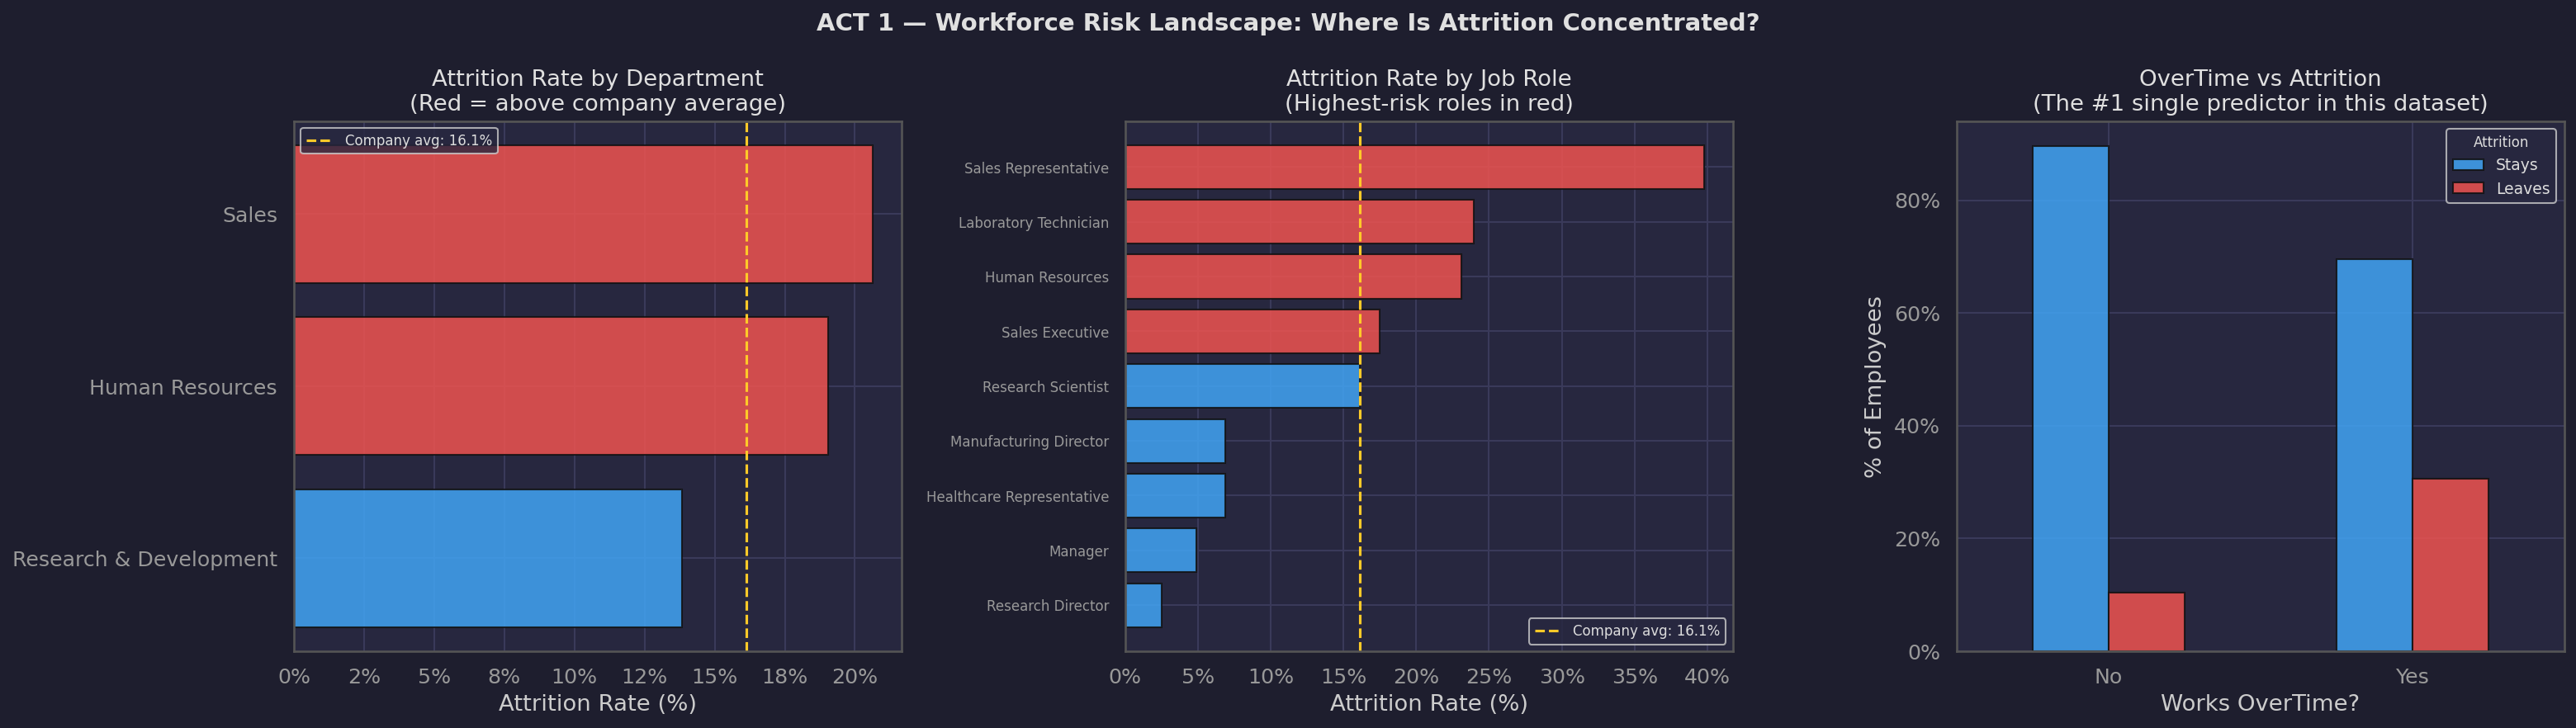

In [ ]:
print("  EDA — ACT 1: WORKFORCE RISK LANDSCAPE")

# Encode attrition as binary for correlation analysis later
df["Attrition_Bin"] = (df["Attrition"] == "Yes").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("ACT 1 — Workforce Risk Landscape: Where Is Attrition Concentrated?",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — Attrition rate by Department
ax = axes[0]
dept_rate = (df.groupby("Department")["Attrition_Bin"]
             .mean()
             .sort_values(ascending=True) * 100)
bar_colors = ["#ef5350" if v > attrition_rate else "#42a5f5"
              for v in dept_rate.values]
bars = ax.barh(dept_rate.index, dept_rate.values,
               color=bar_colors, edgecolor="#111", alpha=0.85)
ax.axvline(attrition_rate, color="#ffca28", lw=1.5, ls="--",
           label=f"Company avg: {attrition_rate:.1f}%")
ax.set_title("Attrition Rate by Department\n(Red = above company average)",
             color="#e0e0e0")
ax.set_xlabel("Attrition Rate (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)

# Panel 2 — Attrition rate by Job Role (sorted)
ax = axes[1]
role_rate = (df.groupby("JobRole")["Attrition_Bin"]
             .mean()
             .sort_values(ascending=True) * 100)
colors_role = ["#ef5350" if v > attrition_rate else "#42a5f5"
               for v in role_rate.values]
ax.barh(role_rate.index, role_rate.values,
        color=colors_role, edgecolor="#111", alpha=0.85)
ax.axvline(attrition_rate, color="#ffca28", lw=1.5, ls="--",
           label=f"Company avg: {attrition_rate:.1f}%")
ax.set_title("Attrition Rate by Job Role\n(Highest-risk roles in red)",
             color="#e0e0e0")
ax.set_xlabel("Attrition Rate (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
ax.tick_params(axis="y", labelsize=8)

# Panel 3 — OverTime vs Attrition (the single strongest raw signal)
ax = axes[2]
ot_data = df.groupby(["OverTime", "Attrition"]).size().unstack(fill_value=0)
ot_pct  = ot_data.div(ot_data.sum(axis=1), axis=0) * 100
ot_pct[["No", "Yes"]].plot(
    kind="bar", ax=ax, color=["#42a5f5", "#ef5350"],
    edgecolor="#111", alpha=0.85, rot=0
)
ax.set_title("OverTime vs Attrition\n(The #1 single predictor in this dataset)",
             color="#e0e0e0")
ax.set_xlabel("Works OverTime?")
ax.set_ylabel("% of Employees")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(["Stays", "Leaves"], fontsize=9, title="Attrition", title_fontsize=8)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────

 Monthly income and years since last promotion are consistently the
     two strongest financial signals for attrition. Employees who feel
     underpaid relative to peers OR who have been passed over for promotion
      repeatedly are the highest flight risks — and both are variables
      the HR team can act on directly (salary review, promotion fast-track).

  EDA — ACT 2: SIGNAL EXTRACTION


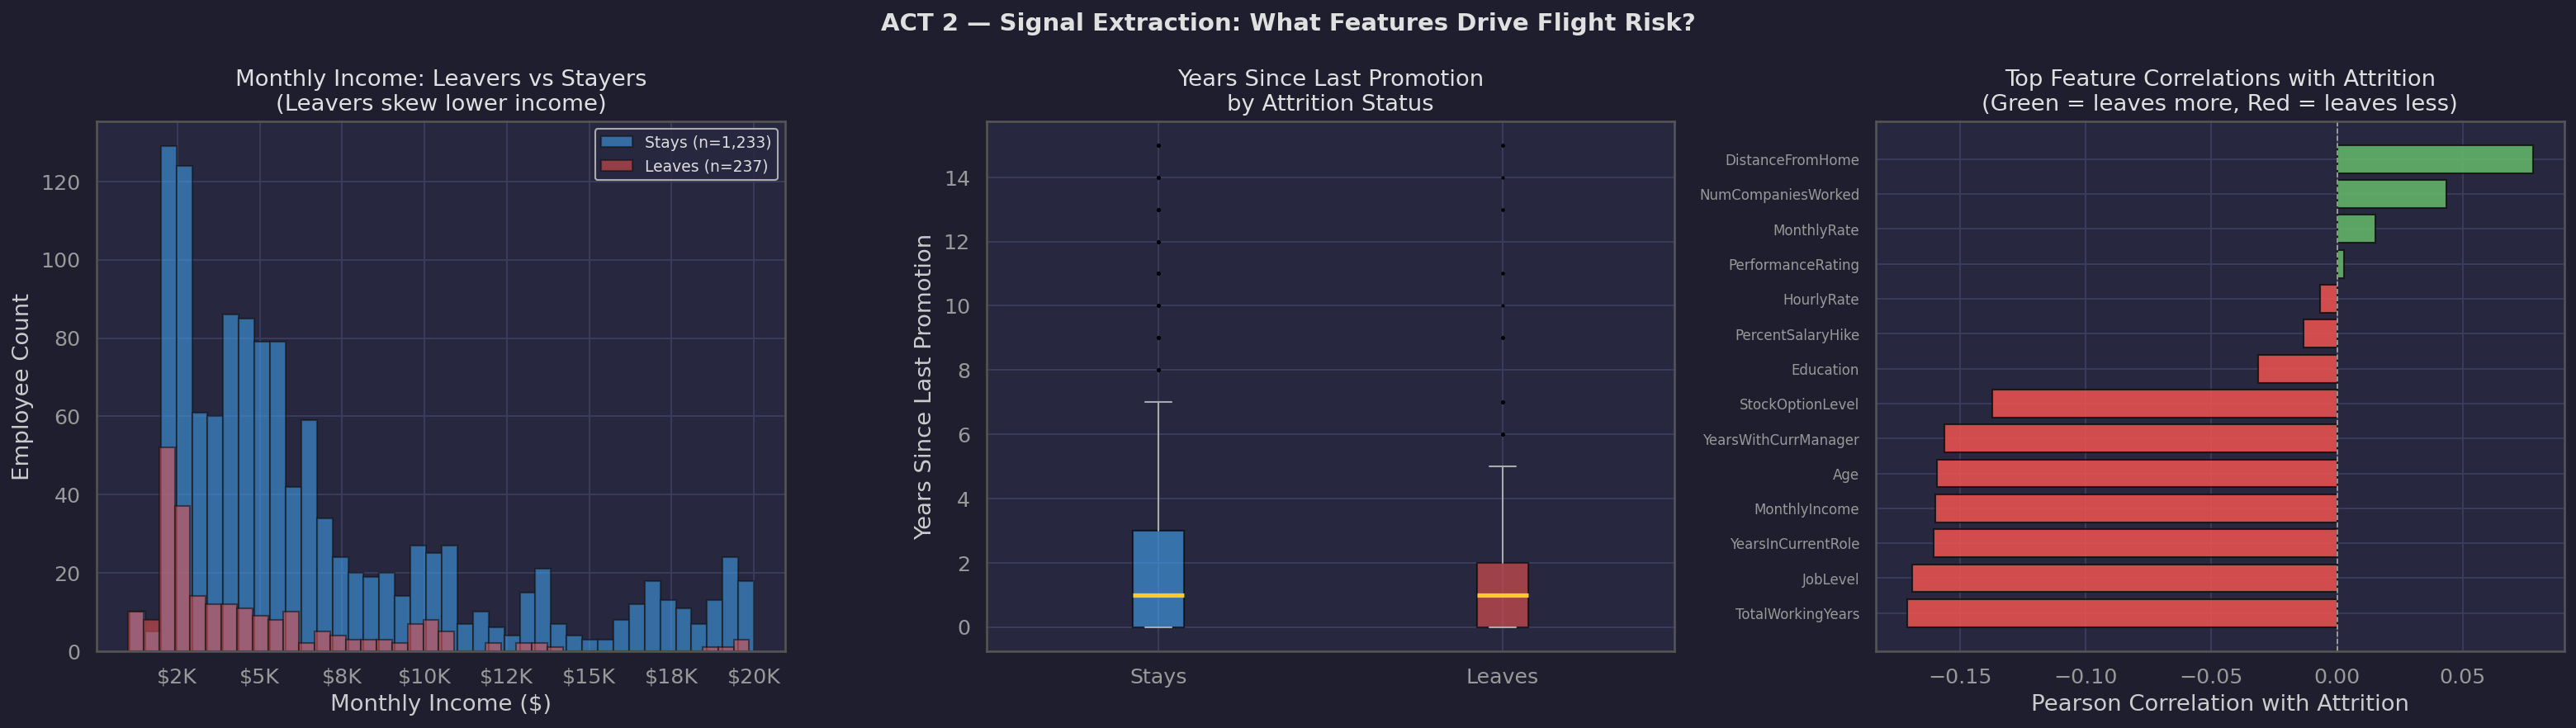

In [ ]:
print("  EDA — ACT 2: SIGNAL EXTRACTION")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("ACT 2 — Signal Extraction: What Features Drive Flight Risk?",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — Monthly Income distribution: Leavers vs Stayers
ax = axes[0]
for label, color, name in [("No", "#42a5f5", "Stays"),
                             ("Yes", "#ef5350", "Leaves")]:
    subset = df[df["Attrition"] == label]["MonthlyIncome"]
    ax.hist(subset, bins=40, alpha=0.55, color=color,
            label=f"{name} (n={len(subset):,})", edgecolor="#111")
ax.set_title("Monthly Income: Leavers vs Stayers\n(Leavers skew lower income)",
             color="#e0e0e0")
ax.set_xlabel("Monthly Income ($)")
ax.set_ylabel("Employee Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e3:.0f}K"))
ax.legend(fontsize=9)

# Panel 2 — YearsSinceLastPromotion vs Attrition (box plot)
ax = axes[1]
data_no  = df[df["Attrition"] == "No"]["YearsSinceLastPromotion"]
data_yes = df[df["Attrition"] == "Yes"]["YearsSinceLastPromotion"]
bp = ax.boxplot(
    [data_no, data_yes],
    labels=["Stays", "Leaves"],
    patch_artist=True, notch=False,
    boxprops=dict(facecolor="#42a5f5", alpha=0.6),
    medianprops=dict(color="#ffca28", lw=2.5),
    whiskerprops=dict(color="#aaa"),
    capprops=dict(color="#aaa"),
    flierprops=dict(marker=".", color="#555", markersize=2)
)
bp["boxes"][1].set_facecolor("#ef5350")
ax.set_title("Years Since Last Promotion\nby Attrition Status",
             color="#e0e0e0")
ax.set_ylabel("Years Since Last Promotion")

# Panel 3 — Top numeric feature correlations with Attrition
ax = axes[2]
numeric_df  = df.select_dtypes(include=[np.number])
corr_target = (numeric_df.corr()["Attrition_Bin"]
               .drop("Attrition_Bin")
               .sort_values())
top_corr    = pd.concat([corr_target.head(7), corr_target.tail(7)])
bar_cols    = ["#ef5350" if v < 0 else "#66bb6a" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values,
        color=bar_cols, edgecolor="#111", alpha=0.85)
ax.axvline(0, color="#aaa", lw=0.8, ls="--")
ax.set_title("Top Feature Correlations with Attrition\n(Green = leaves more, Red = leaves less)",
             color="#e0e0e0")
ax.set_xlabel("Pearson Correlation with Attrition")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()




#Logistic Regression requires all inputs to be numeric.
      This dataset has two types of categorical columns:

   Binary categoricals (2 values) — LabelEncoder is sufficient.
     OverTime: Yes/No → 1/0
    Gender:   Male/Female → 1/0

   Multi-class categoricals (3+ values) — One-Hot Encoding required.
     Department, BusinessTravel, EducationField, JobRole, MaritalStatus
     We use drop_first=True to avoid the dummy variable trap
     (perfect multicollinearity between dummy columns).

#   Target: Attrition Yes → 1, No → 0

In [ ]:
print("  STEP 2 — PREPROCESSING")

df_pre = df.copy()

# 2.1 Encode target
df_pre["Attrition"] = (df_pre["Attrition"] == "Yes").astype(int)
print(f"\n[2.1]  Target encoded: Yes→1, No→0")

  STEP 2 — PREPROCESSING

[2.1]  Target encoded: Yes→1, No→0


In [ ]:

# 2.2 Binary encode two-value categoricals
binary_cols = ["OverTime", "Gender"]
for col in binary_cols:
    df_pre[col] = LabelEncoder().fit_transform(df_pre[col])
print(f"[2.2]  Binary encoded : {binary_cols}")


[2.2]  Binary encoded : ['OverTime', 'Gender']


In [ ]:
multi_cols = ["BusinessTravel", "Department", "EducationField",
              "JobRole", "MaritalStatus"]
for col in multi_cols:
  print(df[col].unique(),"\n")

['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] 

['Sales' 'Research & Development' 'Human Resources'] 

['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources'] 

['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources'] 

['Single' 'Married' 'Divorced'] 



In [ ]:
# 2.3 One-hot encode multi-class categoricals (drop_first avoids dummy trap)
multi_cols = ["BusinessTravel", "Department", "EducationField",
              "JobRole", "MaritalStatus"]

df_pre = pd.get_dummies(df_pre, columns=multi_cols, drop_first=True)
print(f"[2.3]  One-hot encoded: {multi_cols}")

[2.3]  One-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']


In [ ]:
# 2.4 Drop the helper binary column we created in EDA
df_pre.drop(columns=["Attrition_Bin"], inplace=True, errors="ignore")
print(f"\n[2.4]  Shape after preprocessing : {df_pre.shape}")


[2.4]  Shape after preprocessing : (1470, 45)


In [ ]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [ ]:
#checking all columns are in numeric type

print(f"[2.5]  All dtypes numeric         : "
      f"{all(df_pre.dtypes != 'object')}")

[2.5]  All dtypes numeric         : True


# The three engineered features below extract signals that raw columns
      cannot express individually:

#   Satisfaction_Score   
 composite of 4 independent survey dimensions.
                          A single low score might be noise; low scores
                          across ALL dimensions signal genuine disengagement.

#   Tenure_Ratio        
 years in current role / total working years.
                          An employee 8 years into a career but stuck in
                          the same role for 7 years is being under-promoted.
                          This ratio captures career stagnation in one number.

#   Income_vs_Role_Median  
is this employee paid below the median for their
                           job level? Relative underpayment is a stronger
                           flight signal than absolute salary because it
                           captures perceived fairness, not just income level.

In [ ]:
print("  STEP 3 — FEATURE ENGINEERING")

df_feat = df_pre.copy()

# 3.1 Satisfaction composite score (mean of 4 survey dimensions, scale 1-4)
satisfaction_cols = ["EnvironmentSatisfaction", "JobSatisfaction",
                     "RelationshipSatisfaction", "WorkLifeBalance"]
df_feat["Satisfaction_Score"] = df_feat[satisfaction_cols].mean(axis=1)
print(f"[3.1]  Satisfaction_Score = mean of {satisfaction_cols}")


  STEP 3 — FEATURE ENGINEERING
[3.1]  Satisfaction_Score = mean of ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']


In [ ]:
# 3.2 Career stagnation ratio — low value = under-promoted

df_feat["Tenure_Ratio"] = (
    df_feat["YearsInCurrentRole"] / (df_feat["TotalWorkingYears"] + 1)
)
print("[3.2]  Tenure_Ratio = YearsInCurrentRole / (TotalWorkingYears + 1)")


[3.2]  Tenure_Ratio = YearsInCurrentRole / (TotalWorkingYears + 1)


In [ ]:
# 3.3 Income below job-level median — relative underpayment flag
role_median_income  = df_feat.groupby("JobLevel")["MonthlyIncome"].transform("median")
df_feat["Income_vs_Role_Median"] = df_feat["MonthlyIncome"] - role_median_income
print("[3.3]  Income_vs_Role_Median = MonthlyIncome − JobLevel median income")

[3.3]  Income_vs_Role_Median = MonthlyIncome − JobLevel median income


In [ ]:
print(f"\n[3.4]  Shape after feature engineering : {df_feat.shape}")


[3.4]  Shape after feature engineering : (1470, 48)


In [ ]:
print(f"\n[3.5]  New features preview:")
print(df_feat[["Satisfaction_Score", "Tenure_Ratio",
               "Income_vs_Role_Median"]].describe().round(3).to_string())


[3.5]  New features preview:
       Satisfaction_Score  Tenure_Ratio  Income_vs_Role_Median
count            1470.000      1470.000               1470.000
mean                2.731         0.361                 29.229
std                 0.506         0.254               1306.211
min                 1.000         0.000              -5051.000
25%                 2.500         0.154               -599.750
50%                 2.750         0.333                  0.000
75%                 3.000         0.571                733.250
max                 4.000         0.882               4658.000


# class_weight='balanced':
   Only 16% of rows are Attrition=1. An unweighted model trivially learns
   to predict "Stays" for everyone and achieves 84% accuracy while being
   completely useless. class_weight='balanced' tells sklearn to penalise
   misclassifying the minority class (Leavers) by 1/0.16 ≈ 6× more —
   matching the actual business cost asymmetry where a missed leaver
   costs 12× more than a false alarm.

#  StratifiedKFold:
   Standard KFold splits randomly. With 16% minority class, a random split
   could produce a fold with almost no positive examples, making the fold's
   metric unreliable. Stratified splits guarantee each fold mirrors the
   overall 84/16 class ratio.

#  max_iter=1000:
   Logistic Regression uses iterative solvers (lbfgs by default).
   The default 100 iterations sometimes fails to converge on
   datasets with many one-hot-encoded columns. 1000 is safe.

In [ ]:
print("  STEP 4 — MODELLING")

TARGET   = "Attrition"
FEATURES = [c for c in df_feat.columns if c != TARGET]

X = df_feat[FEATURES].values
y = df_feat[TARGET].values

print(f"\n[4.1]  Feature matrix shape : {X.shape}")

df_feat[FEATURES].head(3)

  STEP 4 — MODELLING

[4.1]  Feature matrix shape : (1470, 47)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Satisfaction_Score,Tenure_Ratio,Income_vs_Role_Median
0,41,1102,1,2,2,0,94,3,2,4,...,False,False,False,True,False,False,True,2.0,0.444444,653.0
1,49,279,8,1,3,1,61,2,2,2,...,False,False,True,False,False,True,False,3.0,0.636364,-210.0
2,37,1373,2,2,4,1,92,2,1,3,...,False,False,False,False,False,False,True,3.0,0.000000,-580.0


In [ ]:
print(f"[4.2]  Class distribution   : "
      f"Stays={int((y==0).sum())} ({(y==0).mean():.1%})  "
      f"Leaves={int((y==1).sum())} ({(y==1).mean():.1%})")

[4.2]  Class distribution   : Stays=1233 (83.9%)  Leaves=237 (16.1%)


In [ ]:
# Stratified 5-fold CV — preserves class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
                   class_weight="balanced",   # correct for imbalance
                   max_iter=1000,
                   random_state=42,
                   C=0.5                      # mild L2 regularisation
               ))
])


In [ ]:
# Evaluate on multiple metrics simultaneously
scoring = {
    "roc_auc":   "roc_auc",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
}
cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print(f"\n[4.3]  Cross-validation results (5-fold stratified):\n")
for metric, key in [("ROC-AUC",   "test_roc_auc"),
                     ("Precision", "test_precision"),
                     ("Recall",    "test_recall"),
                     ("F1 Score",  "test_f1")]:
    scores = cv_results[key]
    print(f"  {metric:<12}: {scores.mean():.4f}  ±{scores.std():.4f}  "
          f"(folds: {', '.join([f'{s:.3f}' for s in scores])})")




[4.3]  Cross-validation results (5-fold stratified):

  ROC-AUC     : 0.8275  ±0.0232  (folds: 0.813, 0.831, 0.851, 0.851, 0.791)
  Precision   : 0.3720  ±0.0177  (folds: 0.362, 0.398, 0.360, 0.388, 0.352)
  Recall      : 0.7047  ±0.0349  (folds: 0.708, 0.688, 0.766, 0.702, 0.660)
  F1 Score    : 0.4863  ±0.0161  (folds: 0.479, 0.504, 0.490, 0.500, 0.459)


In [ ]:
print(f"\n[4.4]  WHY recall matters more than precision here:")
print(f"       A missed leaver (False Negative) costs ~6 months salary.")
print(f"       A false alarm  (False Positive) costs ~0.5 months (retention bonus).\n")
print(f"       Recall = {cv_results['test_recall'].mean():.1%} means we catch "
      f"{cv_results['test_recall'].mean():.1%} of all actual leavers.")

# Refit on full dataset for threshold analysis
model.fit(X, y)
y_proba = model.predict_proba(X)[:, 1]


[4.4]  WHY recall matters more than precision here:
       A missed leaver (False Negative) costs ~6 months salary.
       A false alarm  (False Positive) costs ~0.5 months (retention bonus).

       Recall = 70.5% means we catch 70.5% of all actual leavers.



# : Logistic Regression outputs a probability [0.0, 1.0].
      The default decision threshold is 0.5 — flag as "will leave" if P > 0.5.
      But 0.5 was chosen arbitrarily. Given our cost asymmetry
      (False Negatives cost 12× more than False Positives), we should
      lower the threshold so we flag more people as at-risk.

      Optimal threshold = the point on the Precision-Recall curve that
      maximises F1-score, which is the harmonic mean of precision and recall.
      We could also minimise total business cost — demonstrated below.

In [ ]:
print("  STEP 5 — THRESHOLD OPTIMISATION & BUSINESS COST ANALYSIS")

# Cost assumptions (in months of average salary)
COST_FALSE_NEGATIVE = 6.0   # missed leaver → full replacement cost
COST_FALSE_POSITIVE = 0.5   # false alarm  → retention bonus wasted

# Average monthly income from dataset (used as £ proxy)
avg_monthly_income = df["MonthlyIncome"].mean()
print(f"\n[5.1]  Average monthly income    : ${avg_monthly_income:,.0f}")
print(f"[5.2]  Cost per False Negative   : "
      f"${COST_FALSE_NEGATIVE * avg_monthly_income:,.0f} (6 months salary)")
print(f"[5.3]  Cost per False Positive   : "
      f"${COST_FALSE_POSITIVE * avg_monthly_income:,.0f} (0.5 months salary)")

  STEP 5 — THRESHOLD OPTIMISATION & BUSINESS COST ANALYSIS

[5.1]  Average monthly income    : $6,503
[5.2]  Cost per False Negative   : $39,018 (6 months salary)
[5.3]  Cost per False Positive   : $3,251 (0.5 months salary)


In [ ]:
# Sweep thresholds from 0.1 to 0.9 and compute total business cost
thresholds    = np.arange(0.10, 0.91, 0.01)
business_costs = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t).ravel()
    cost = (fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE) * avg_monthly_income
    business_costs.append(cost)

best_thresh_idx  = np.argmin(business_costs)
best_thresh      = thresholds[best_thresh_idx]
best_cost        = business_costs[best_thresh_idx]
default_cost     = business_costs[np.argmin(np.abs(thresholds - 0.50))]

print(f"\n[5.4]  Default threshold (0.50) total cost  : ${default_cost:,.0f}")
print(f"[5.5]  Optimal threshold ({best_thresh:.2f}) total cost : ${best_cost:,.0f}")
print(f"[5.6]  Estimated savings vs default           : "
      f"${default_cost - best_cost:,.0f}  "
      f"({(default_cost - best_cost) / default_cost:.1%} reduction)")




[5.4]  Default threshold (0.50) total cost  : $2,731,231
[5.5]  Optimal threshold (0.40) total cost : $2,295,535
[5.6]  Estimated savings vs default           : $435,696  (16.0% reduction)


In [ ]:
# Final predictions at optimal threshold
y_pred_optimal = (y_proba >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred_optimal).ravel()

print(f"\n[5.7]  Confusion matrix at threshold={best_thresh:.2f}:")
print(f"       True  Positives (caught leavers)     : {tp}")
print(f"       False Positives (false alarms)        : {fp}")
print(f"       False Negatives (missed leavers)      : {fn}")
print(f"       True  Negatives (correct stayers)     : {tn}")

print(f"\n[5.8]  Classification Report (threshold={best_thresh:.2f}):")
print(classification_report(y, y_pred_optimal,
                             target_names=["Stays", "Leaves"]))


[5.7]  Confusion matrix at threshold=0.40:
       True  Positives (caught leavers)     : 209
       False Positives (false alarms)        : 370
       False Negatives (missed leavers)      : 28
       True  Negatives (correct stayers)     : 863

[5.8]  Classification Report (threshold=0.40):
              precision    recall  f1-score   support

       Stays       0.97      0.70      0.81      1233
      Leaves       0.36      0.88      0.51       237

    accuracy                           0.73      1470
   macro avg       0.66      0.79      0.66      1470
weighted avg       0.87      0.73      0.76      1470



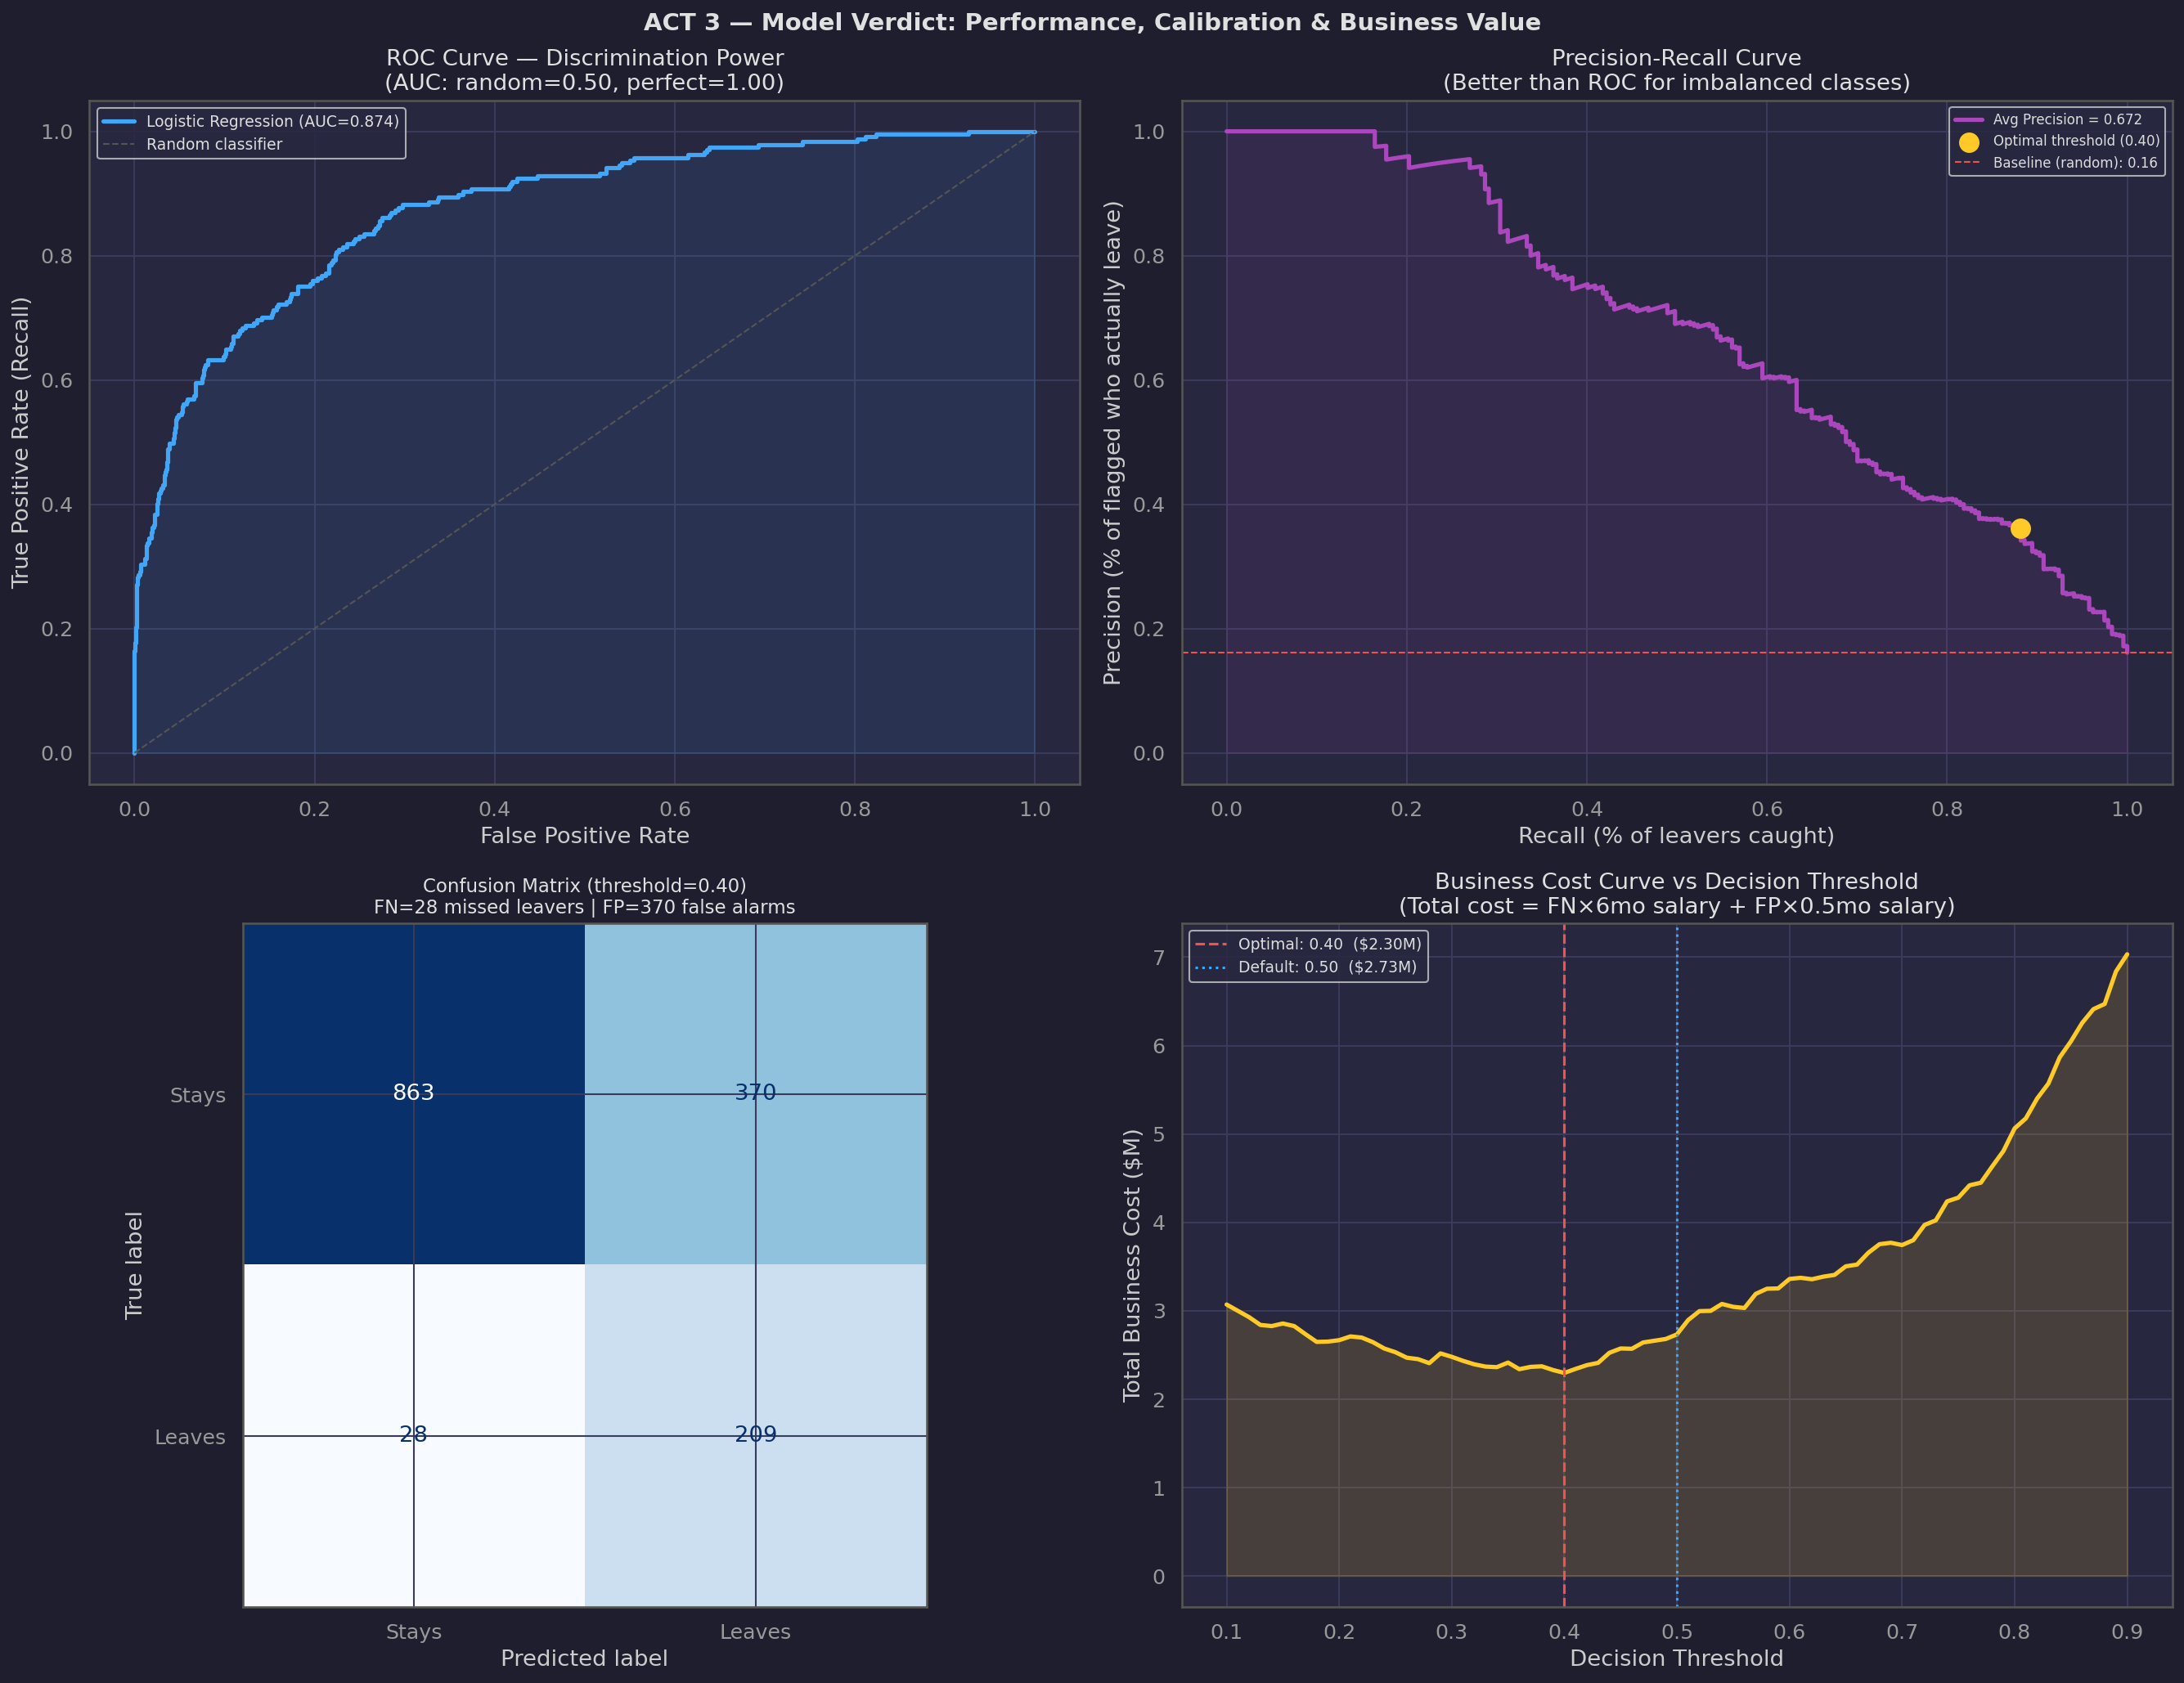

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("ACT 3 — Model Verdict: Performance, Calibration & Business Value",
             fontsize=14, color="#e0e0e0", fontweight="bold")

# Panel 1 — ROC Curve
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y, y_proba)
auc_score   = roc_auc_score(y, y_proba)
ax.plot(fpr, tpr, color="#42a5f5", lw=2.5, label=f"Logistic Regression (AUC={auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="#555", lw=1, ls="--", label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="#42a5f5")
ax.set_title("ROC Curve — Discrimination Power\n(AUC: random=0.50, perfect=1.00)",
             color="#e0e0e0")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(fontsize=9)

# Panel 2 — Precision-Recall Curve with optimal threshold marker
ax = axes[0, 1]
prec, rec, pr_thresh = precision_recall_curve(y, y_proba)
ap_score = average_precision_score(y, y_proba)
ax.plot(rec, prec, color="#ab47bc", lw=2.5,
        label=f"Avg Precision = {ap_score:.3f}")
ax.fill_between(rec, prec, alpha=0.1, color="#ab47bc")
# Mark the optimal threshold point
opt_prec = precision_recall_curve(y, y_proba)[0]
opt_rec  = precision_recall_curve(y, y_proba)[1]
proba_thresh_arr = precision_recall_curve(y, y_proba)[2]
idx_opt  = np.argmin(np.abs(proba_thresh_arr - best_thresh))
ax.scatter(opt_rec[idx_opt], opt_prec[idx_opt],
           s=120, color="#ffca28", zorder=5,
           label=f"Optimal threshold ({best_thresh:.2f})")
ax.axhline(y.mean(), color="#ef5350", lw=1, ls="--",
           label=f"Baseline (random): {y.mean():.2f}")
ax.set_title("Precision-Recall Curve\n(Better than ROC for imbalanced classes)",
             color="#e0e0e0")
ax.set_xlabel("Recall (% of leavers caught)")
ax.set_ylabel("Precision (% of flagged who actually leave)")
ax.legend(fontsize=8)

# Panel 3 — Confusion matrix at optimal threshold
ax = axes[1, 0]
cm   = confusion_matrix(y, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Stays", "Leaves"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix (threshold={best_thresh:.2f})\n"
             f"FN={fn} missed leavers | FP={fp} false alarms",
             color="#e0e0e0")
ax.title.set_fontsize(11)

# Panel 4 — Business cost curve across thresholds
ax = axes[1, 1]
ax.plot(thresholds, [c / 1e6 for c in business_costs],
        color="#ffca28", lw=2.5)
ax.axvline(best_thresh, color="#ef5350", lw=1.5, ls="--",
           label=f"Optimal: {best_thresh:.2f}  (${best_cost/1e6:.2f}M)")
ax.axvline(0.50, color="#42a5f5", lw=1.5, ls=":",
           label=f"Default: 0.50  (${default_cost/1e6:.2f}M)")
ax.fill_between(thresholds,
                [c / 1e6 for c in business_costs],
                alpha=0.15, color="#ffca28")
ax.set_title("Business Cost Curve vs Decision Threshold\n"
             "(Total cost = FN×6mo salary + FP×0.5mo salary)",
             color="#e0e0e0")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Business Cost ($M)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────

#  Model output without a business action is just a number.
      This cell translates attrition probability into a 3-tier risk
      system that HR managers can act on directly:

        High Risk   (P ≥ 0.60) → immediate 1:1 manager conversation,
                                  salary review, fast-track promotion eval
        Medium Risk (0.35-0.60) → check-in meeting, engagement survey,
                                  PIP review if performance is also low
        Low Risk    (P < 0.35)  → standard engagement, no intervention needed

      Replacement cost estimate = 6 months of that employee's monthly income
     This makes the output directly usable in HR budget planning

In [ ]:
print("  STEP 6 — EMPLOYEE RISK TIER TABLE")

# Rebuild original df aligned to model input for output table
risk_df = pd.read_csv(FILE_PATH)
risk_df = risk_df.drop(columns=CONSTANT_COLS, errors="ignore")

risk_df["Attrition_Probability"] = y_proba
risk_df["Actual_Attrition"]      = (risk_df["Attrition"] == "Yes").astype(int)
risk_df["Replacement_Cost_Est"]  = risk_df["MonthlyIncome"] * COST_FALSE_NEGATIVE

def assign_risk_tier(p):
    if p >= 0.60:
        return "🔴 High Risk"
    elif p >= 0.35:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"

risk_df["Risk_Tier"] = risk_df["Attrition_Probability"].apply(assign_risk_tier)




  STEP 6 — EMPLOYEE RISK TIER TABLE


In [ ]:

# Summary by risk tier
tier_summary = risk_df.groupby("Risk_Tier").agg(
    Employees         = ("JobRole", "count"),
    Avg_Attrition_Prob= ("Attrition_Probability", "mean"),
    Actual_Leavers    = ("Actual_Attrition", "sum"),
    Avg_Replacement_Cost = ("Replacement_Cost_Est", "mean"),
    Total_At_Stake    = ("Replacement_Cost_Est", "sum"),
).round(2)

print(f"\n[6.1]  Employee Risk Tier Summary:")
print(tier_summary.to_string())



[6.1]  Employee Risk Tier Summary:
               Employees  Avg_Attrition_Prob  Actual_Leavers  Avg_Replacement_Cost  Total_At_Stake
Risk_Tier                                                                                         
🔴 High Risk          347                0.79             166              28467.27       9878142.0
🟡 Medium Risk        307                0.47              46              33667.97      10336068.0
🟢 Low Risk           816                0.14              25              45516.72      37141644.0


In [ ]:

# Top 10 highest-risk employees
print(f"\n[6.2]  Top 10 Highest-Risk Employees (for HR action):")
top_risk = (risk_df[["JobRole", "Department", "MonthlyIncome",
                       "YearsAtCompany", "OverTime",
                       "Attrition_Probability", "Risk_Tier",
                       "Replacement_Cost_Est"]]
            .sort_values("Attrition_Probability", ascending=False)
            .head(10))
top_risk["Attrition_Probability"] = top_risk["Attrition_Probability"].map("{:.1%}".format)
top_risk["Replacement_Cost_Est"]  = top_risk["Replacement_Cost_Est"].map("${:,.0f}".format)
print(top_risk.to_string(index=False))



[6.2]  Top 10 Highest-Risk Employees (for HR action):
              JobRole             Department  MonthlyIncome  YearsAtCompany OverTime Attrition_Probability   Risk_Tier Replacement_Cost_Est
Laboratory Technician Research & Development           2340               1      Yes                 99.6% 🔴 High Risk              $14,040
 Sales Representative                  Sales           2174               3      Yes                 99.3% 🔴 High Risk              $13,044
Laboratory Technician Research & Development           3172               0      Yes                 99.2% 🔴 High Risk              $19,032
 Sales Representative                  Sales           1118               1      Yes                 99.1% 🔴 High Risk               $6,708
 Sales Representative                  Sales           1878               0      Yes                 98.9% 🔴 High Risk              $11,268
 Sales Representative                  Sales           2121               1      Yes                 98.5

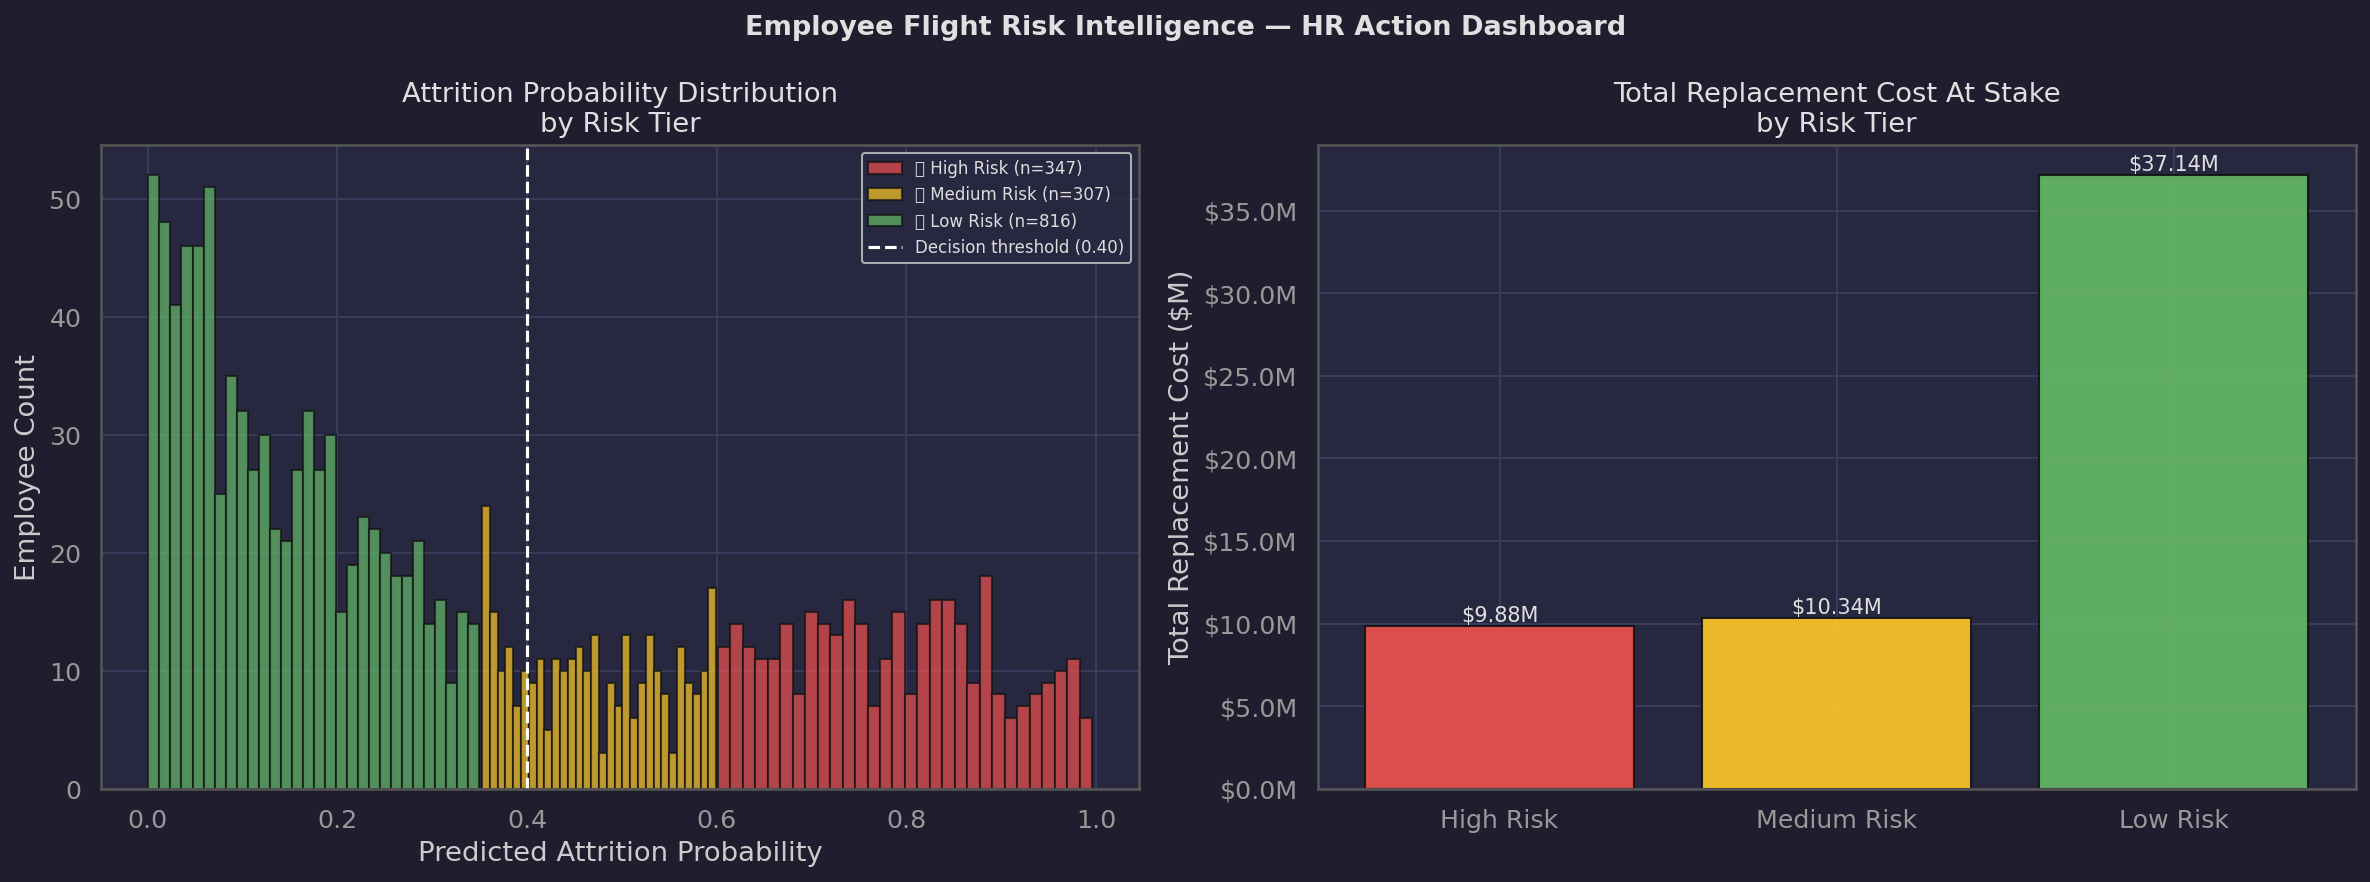

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Employee Flight Risk Intelligence — HR Action Dashboard",
             fontsize=13, color="#e0e0e0", fontweight="bold")

# Panel 1 — Attrition probability distribution coloured by risk tier
ax = axes[0]
tier_palette = {"🔴 High Risk": "#ef5350",
                "🟡 Medium Risk": "#ffca28",
                "🟢 Low Risk": "#66bb6a"}
for tier, color in tier_palette.items():
    subset = risk_df[risk_df["Risk_Tier"] == tier]["Attrition_Probability"]
    ax.hist(subset, bins=30, alpha=0.7, color=color,
            label=f"{tier} (n={len(subset)})", edgecolor="#111")
ax.axvline(best_thresh, color="#fff", lw=1.5, ls="--",
           label=f"Decision threshold ({best_thresh:.2f})")
ax.set_title("Attrition Probability Distribution\nby Risk Tier",
             color="#e0e0e0")
ax.set_xlabel("Predicted Attrition Probability")
ax.set_ylabel("Employee Count")
ax.legend(fontsize=8)

# Panel 2 — Total replacement cost at stake by risk tier
ax = axes[1]
tier_order  = ["🔴 High Risk", "🟡 Medium Risk", "🟢 Low Risk"]
tier_costs  = [tier_summary.loc[t, "Total_At_Stake"] / 1e6
               if t in tier_summary.index else 0
               for t in tier_order]
tier_colors = ["#ef5350", "#ffca28", "#66bb6a"]
bars = ax.bar([t.split(" ", 1)[1] for t in tier_order],
              tier_costs, color=tier_colors, edgecolor="#111", alpha=0.9)
ax.set_title("Total Replacement Cost At Stake\nby Risk Tier",
             color="#e0e0e0")
ax.set_ylabel("Total Replacement Cost ($M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:.1f}M"))
for bar, val in zip(bars, tier_costs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"${val:.2f}M", ha="center", va="bottom",
            fontsize=10, color="#e0e0e0")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────

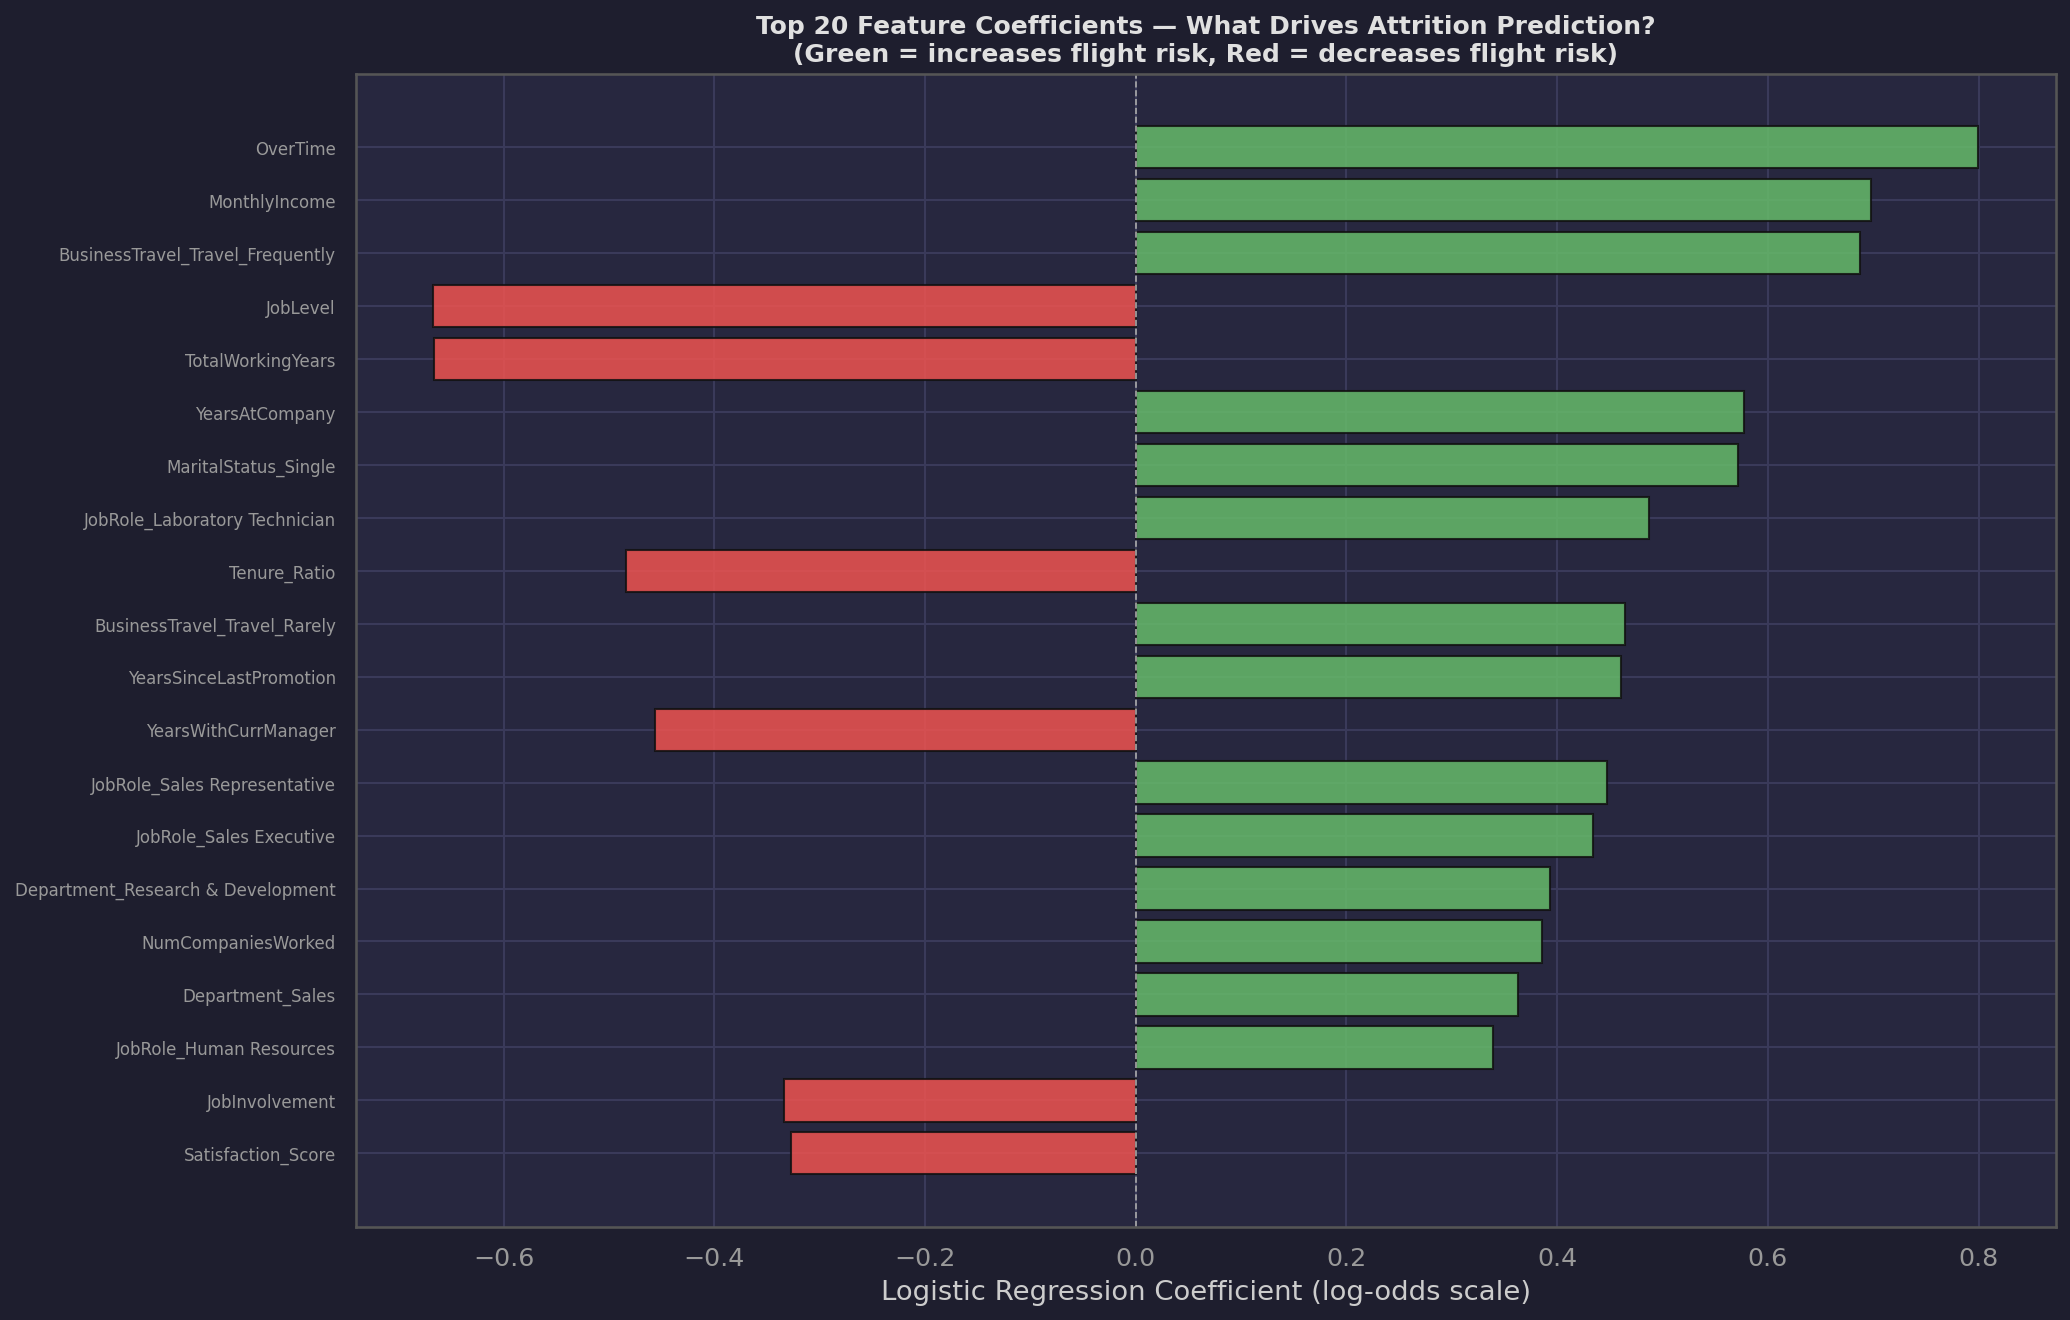

In [ ]:


fig, ax = plt.subplots(figsize=(14, 9))

lr_model      = model.named_steps["clf"]
feature_names = FEATURES
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef":    lr_model.coef_[0]
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=True).tail(20)

bar_cols = ["#66bb6a" if c > 0 else "#ef5350" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"],
        color=bar_cols, edgecolor="#111", alpha=0.85)
ax.axvline(0, color="#aaa", lw=0.8, ls="--")
ax.set_title("Top 20 Feature Coefficients — What Drives Attrition Prediction?\n"
             "(Green = increases flight risk, Red = decreases flight risk)",
             fontsize=12, color="#e0e0e0", fontweight="bold")
ax.set_xlabel("Logistic Regression Coefficient (log-odds scale)")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────

In [ ]:

print("═" * 60)
print("  ✓ PIPELINE COMPLETE — ATTRITION MODEL SUMMARY")
print("═" * 60)

high_risk_n    = (risk_df["Risk_Tier"] == "🔴 High Risk").sum()
high_risk_cost = tier_summary.loc["🔴 High Risk", "Total_At_Stake"] \
                 if "🔴 High Risk" in tier_summary.index else 0

print(f"""
  Project     : Employee Attrition Early-Warning System
  Dataset     : IBM HR Analytics (Kaggle) — {len(df):,} employees
  Target      : Attrition (Yes/No) — {y.mean():.1%} base rate

  ─────────────────────────────────────────────────────
  Pipeline Steps:
    1. Load & validate — drop 4 constant/ID columns
    2. EDA — 3-act visual narrative (7 charts)
    3. Preprocessing — binary label + one-hot encoding
    4. Feature Engineering — Satisfaction_Score,
       Tenure_Ratio, Income_vs_Role_Median
    5. Modelling — Logistic Regression, class_weight=balanced,
       StratifiedKFold CV (5-fold)
    6. Threshold optimisation — business cost curve sweep
    7. Risk tier table — High/Medium/Low with HR action plan
  ─────────────────────────────────────────────────────
  Model ROC-AUC     : {roc_auc_score(y, y_proba):.4f}
  Optimal Threshold : {best_thresh:.2f}  (cost-minimising)
  Cost Saved vs 0.5 : ${(default_cost - best_cost):,.0f}

  High-Risk Employees   : {high_risk_n}
  Replacement Cost Risk : ${high_risk_cost:,.0f}


""")

════════════════════════════════════════════════════════════
  ✓ PIPELINE COMPLETE — ATTRITION MODEL SUMMARY
════════════════════════════════════════════════════════════

  Project     : Employee Attrition Early-Warning System
  Dataset     : IBM HR Analytics (Kaggle) — 1,470 employees
  Target      : Attrition (Yes/No) — 16.1% base rate

  ─────────────────────────────────────────────────────
  Pipeline Steps:
    1. Load & validate — drop 4 constant/ID columns
    2. EDA — 3-act visual narrative (7 charts)
    3. Preprocessing — binary label + one-hot encoding
    4. Feature Engineering — Satisfaction_Score,
       Tenure_Ratio, Income_vs_Role_Median
    5. Modelling — Logistic Regression, class_weight=balanced,
       StratifiedKFold CV (5-fold)
    6. Threshold optimisation — business cost curve sweep
    7. Risk tier table — High/Medium/Low with HR action plan
  ─────────────────────────────────────────────────────
  Model ROC-AUC     : 0.8740
  Optimal Threshold : 0.40  (cost-min